# Exploratory Data Analysis (EDA) Pipeline
## 2026 Bangladesh National Election & July Charter Referendum

**What is EDA?**
Exploratory Data Analysis (EDA) is the critical first step in the data science process. Before building complex machine learning models or testing hypotheses, we use EDA to:
1. Understand the shape, size, and cleanliness of the dataset.
2. Uncover underlying structures and distributions (e.g., Are most constituencies poor or wealthy? Is turnout normally distributed?).
3. Identify correlations between variables (e.g., Does high internet access correlate with higher education?).
4. Detect anomalies, outliers, or missing data.

This notebook performs a comprehensive EDA on the `grand_df_enriched` dataset.


In [1]:
!pip install pyspark -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

spark = SparkSession.builder.appName("Election_EDA").getOrCreate()

# Academic Visualization Configuration
plt.rcParams.update({
    'figure.figsize': (12, 7), 'figure.dpi': 120,
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.grid': True, 'grid.alpha': 0.3
})

PALETTE_BNP = '#1B5E20'
PALETTE_JAMAAT = '#B71C1C'
PALETTE_ACCENT = '#1565C0'
PALETTE_NEUTRAL = '#37474F'

print("Environment setup complete.")

Environment setup complete.


In [2]:
# Load the enriched dataframe
data_path = "/content/grand_df_enriched.csv"
try:
    grand_df = spark.read.csv(data_path, header=True, inferSchema=True)
    print(f"Successfully loaded dataset with {grand_df.count()} rows and {len(grand_df.columns)} columns.")
except Exception as e:
    print(f"Error loading data: {e}")

# Cast features to DoubleType for numerical operations
numeric_columns = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "First_Time_Voter_Pct",
    "NEET_Youth_Pct", "Female_Pop_Pct", "Pucca_Pct", "Extreme_Poverty_Pct",
    "WPI_Log", "Organized_Learning_Pct", "Sanitation_Pct", "Electricity_Pct",
    "Clean_Fuel_Pct", "Internet_Pct", "Financial_Inclusion_Pct",
    "Digital_Youth_Index", "Urban_Proxy", "Infrastructure_Composite",
    "Deprivation_Index", "Voter_Turnout_Pct", "YES_Pct", "NO_Pct",
    "Winner_Vote_Share_Pct", "Victory_Margin_Pct"
]

for f in numeric_columns:
    if f in grand_df.columns:
        grand_df = grand_df.withColumn(f, F.col(f).cast(DoubleType()))

# Convert to Pandas for rapid EDA visualization
pdf = grand_df.toPandas()
print("Data loaded into Pandas DataFrame for visualization.")

Successfully loaded dataset with 269 rows and 38 columns.
Data loaded into Pandas DataFrame for visualization.


## 1. Dataset Overview & Summary Statistics
We begin by looking at the raw structure of the data, the summary statistics (mean, min, max, standard deviation) of our numeric features, and checking for any missing values (Nulls).


In [3]:
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

print("\n--- Missing Values Check ---")
missing_data = pdf.isnull().sum()
print(missing_data[missing_data > 0])

print("\n--- Summary Statistics (Demographics) ---")
display(pdf[["Youth_Electorate_Pct", "Extreme_Poverty_Pct", "Internet_Pct", "Pucca_Pct", "Organized_Learning_Pct"]].describe().round(2))

print("\n--- Summary Statistics (Electoral) ---")
display(pdf[["Voter_Turnout_Pct", "YES_Pct", "NO_Pct", "Victory_Margin_Pct"]].describe().round(2))

DATASET OVERVIEW

--- Missing Values Check ---
Voter_Turnout_Pct            1
Total_Valid_Votes            1
Total_Registered_Voters      1
YES_Pct                    101
NO_Pct                     101
Winner_Vote_Share_Pct        1
Victory_Margin_Pct           1
dtype: int64

--- Summary Statistics (Demographics) ---


,Youth_Electorate_Pct,Extreme_Poverty_Pct,Internet_Pct,Pucca_Pct,Organized_Learning_Pct
count,269.00,269.00,269.00,269.00,269.00
mean,38.19,59.81,29.00,22.37,55.64
std,4.33,22.19,11.00,20.41,5.96
min,29.01,1.27,13.31,1.42,37.95
25%,34.68,47.67,20.86,7.31,51.51
50%,37.65,63.98,26.64,15.77,56.04
75%,41.71,76.26,34.67,30.10,59.38
max,50.32,90.33,75.12,94.16,70.88



--- Summary Statistics (Electoral) ---


,Voter_Turnout_Pct,YES_Pct,NO_Pct,Victory_Margin_Pct
count,268.00,168.00,168.00,268.00
mean,60.18,66.72,33.28,19.11
std,9.39,10.53,10.53,14.73
min,37.09,24.23,18.00,0.18
25%,54.24,62.83,26.48,7.48
50%,59.48,68.41,31.59,16.05
75%,67.80,73.52,37.17,26.61
max,78.22,82.00,75.77,67.28


## 2. Target Variable Distributions
Understanding the spread of our primary target variables: Which political coalitions won the most seats, and what was the distribution of voter turnout and referendum support?


/tmp/ipykernel_8922/207318572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pdf, x="Coalition", palette=[PALETTE_JAMAAT, PALETTE_BNP, PALETTE_NEUTRAL], order=pdf["Coalition"].value_counts().index, ax=axes[0])


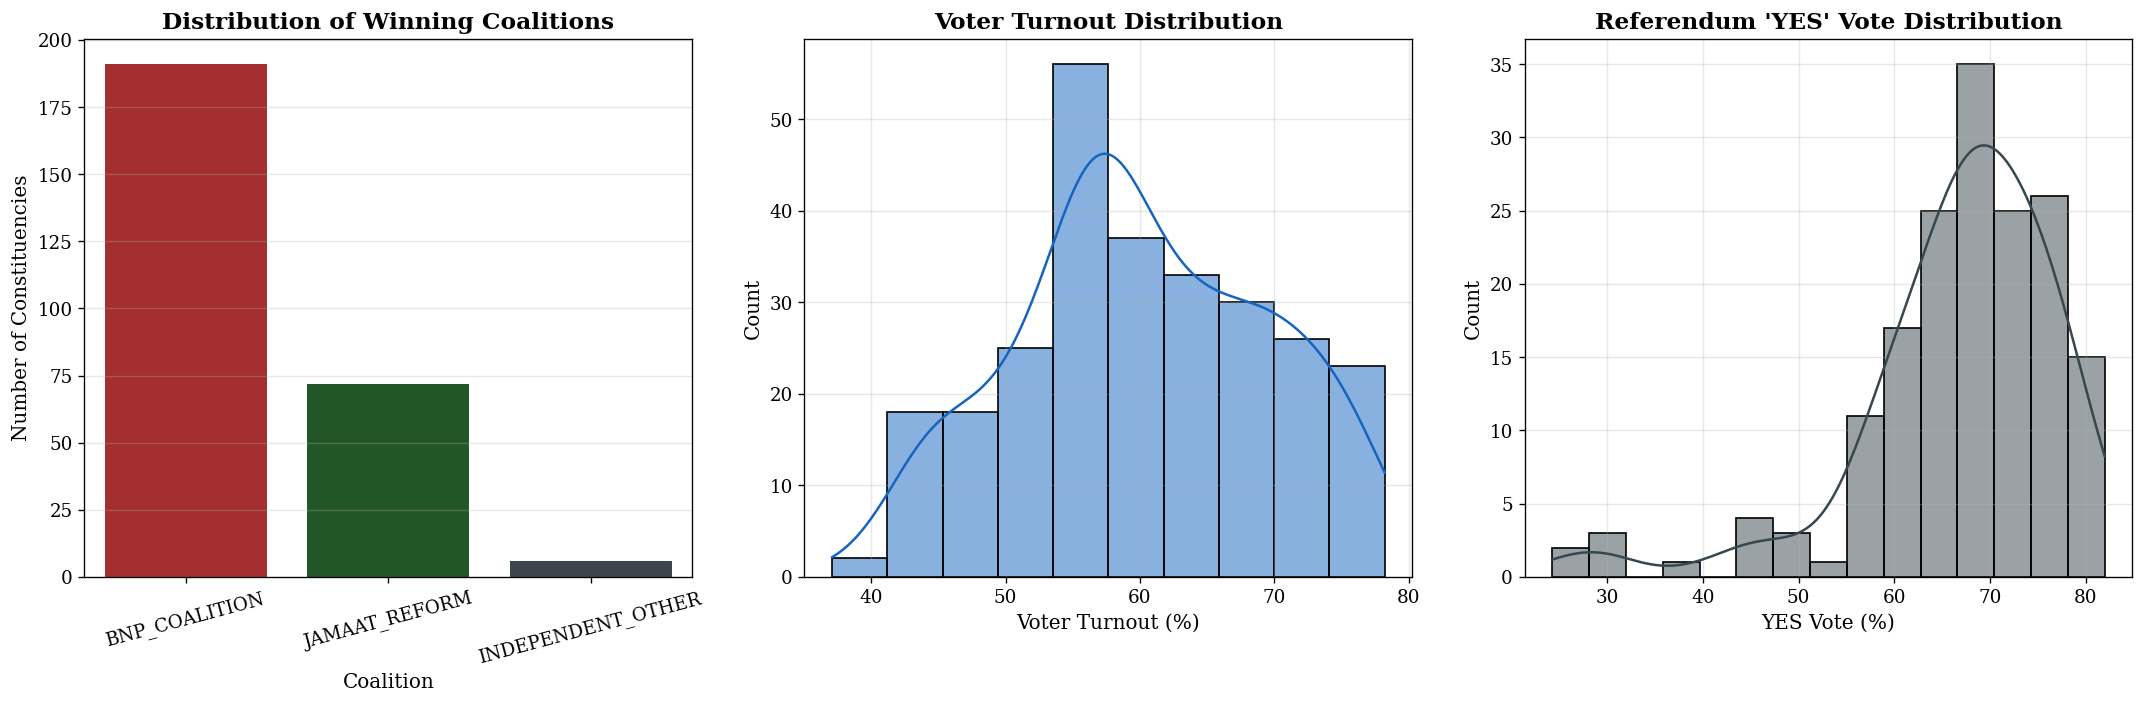

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Winning Coalition Count
sns.countplot(data=pdf, x="Coalition", palette=[PALETTE_JAMAAT, PALETTE_BNP, PALETTE_NEUTRAL], order=pdf["Coalition"].value_counts().index, ax=axes[0])
axes[0].set_title("Distribution of Winning Coalitions")
axes[0].set_ylabel("Number of Constituencies")
axes[0].tick_params(axis='x', rotation=15)

# Subplot 2: Voter Turnout Distribution
sns.histplot(data=pdf, x="Voter_Turnout_Pct", kde=True, color=PALETTE_ACCENT, ax=axes[1])
axes[1].set_title("Voter Turnout Distribution")
axes[1].set_xlabel("Voter Turnout (%)")

# Subplot 3: Referendum YES Vote Distribution
sns.histplot(data=pdf, x="YES_Pct", kde=True, color=PALETTE_NEUTRAL, ax=axes[2])
axes[2].set_title("Referendum 'YES' Vote Distribution")
axes[2].set_xlabel("YES Vote (%)")

plt.tight_layout()
plt.show()

## 3. Socio-Economic Feature Distributions (Univariate Analysis)
We visualize the shape of our key demographic drivers. For example, is extreme poverty skewed? Are urban proxies normally distributed?


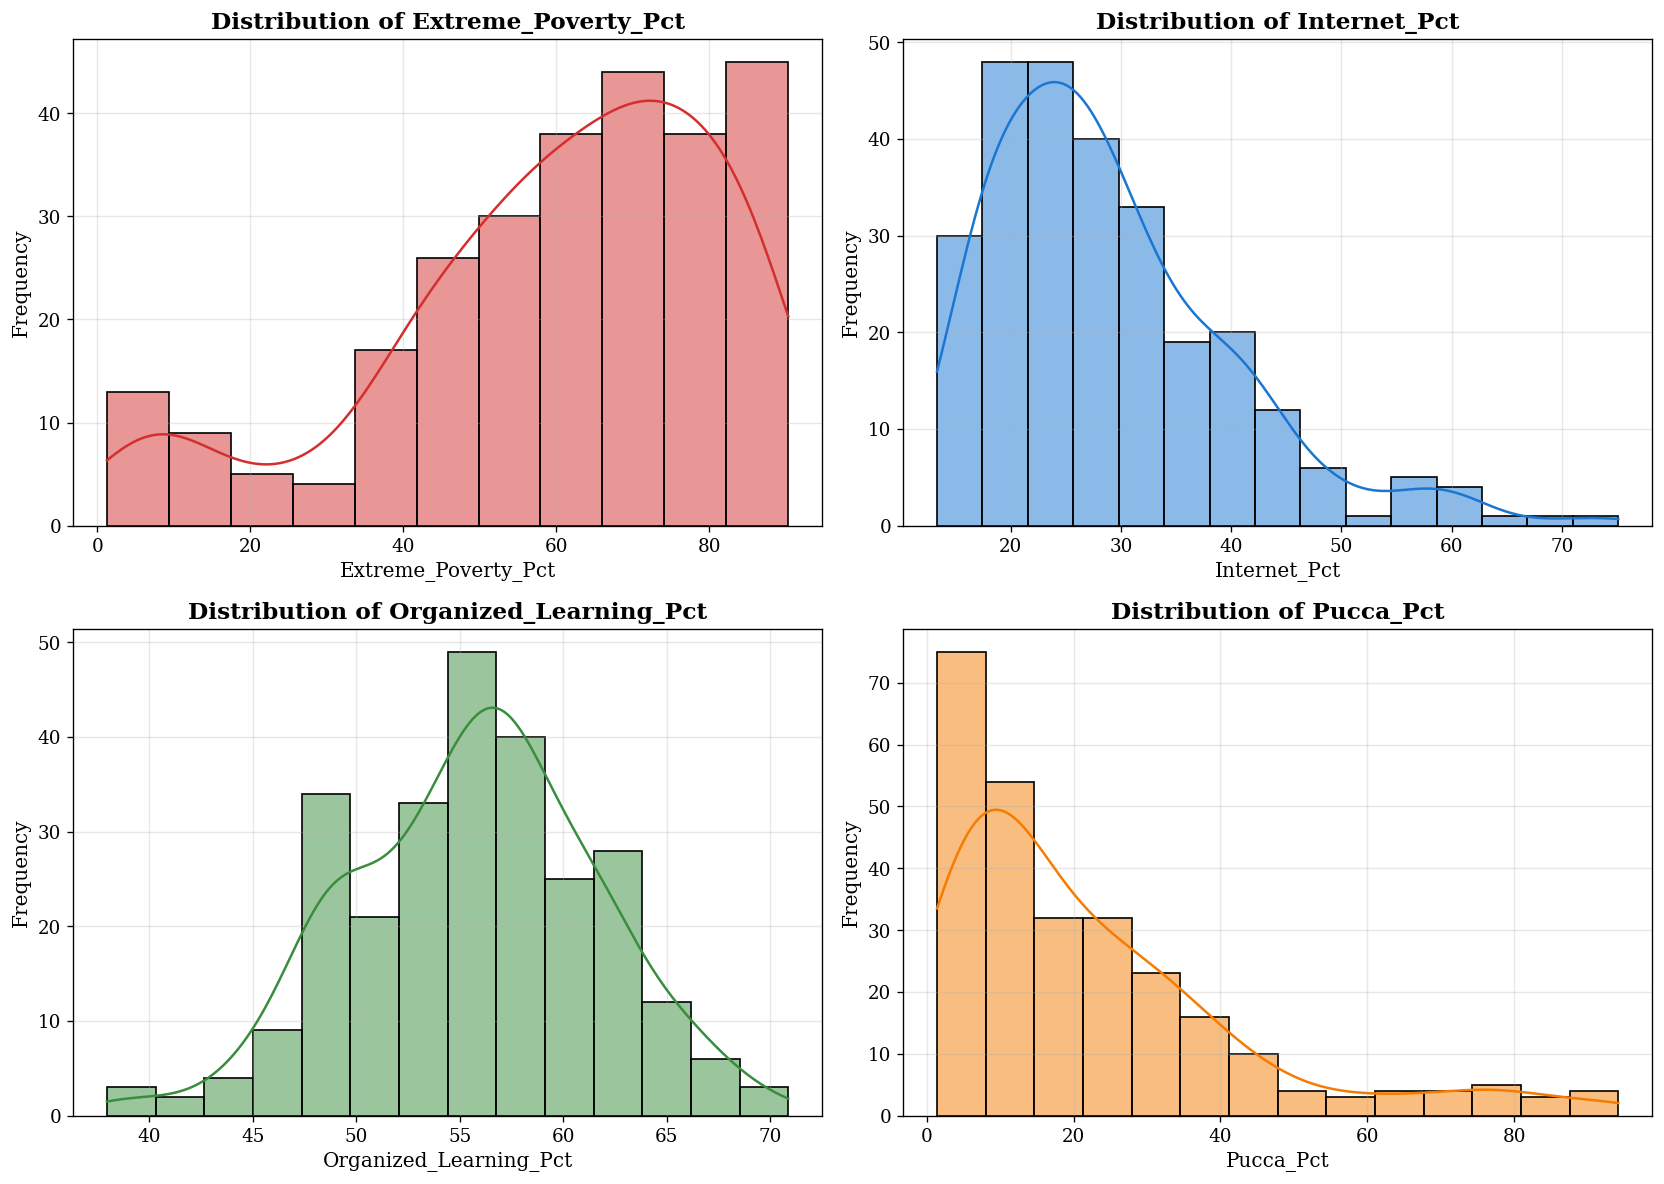

In [5]:
features_to_plot = ["Extreme_Poverty_Pct", "Internet_Pct", "Organized_Learning_Pct", "Pucca_Pct"]
colors = ['#d32f2f', '#1976d2', '#388e3c', '#f57c00']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(pdf[feature], kde=True, color=colors[i], ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Correlation Analysis (Bivariate Analysis)
A correlation matrix reveals linear relationships between all continuous variables. A value of `1.0` means perfect positive correlation, `-1.0` means perfect negative correlation, and `0` means no correlation.

**Key things to look for:**
- Does poverty negatively correlate with education?
- Does internet access positively correlate with urbanization?


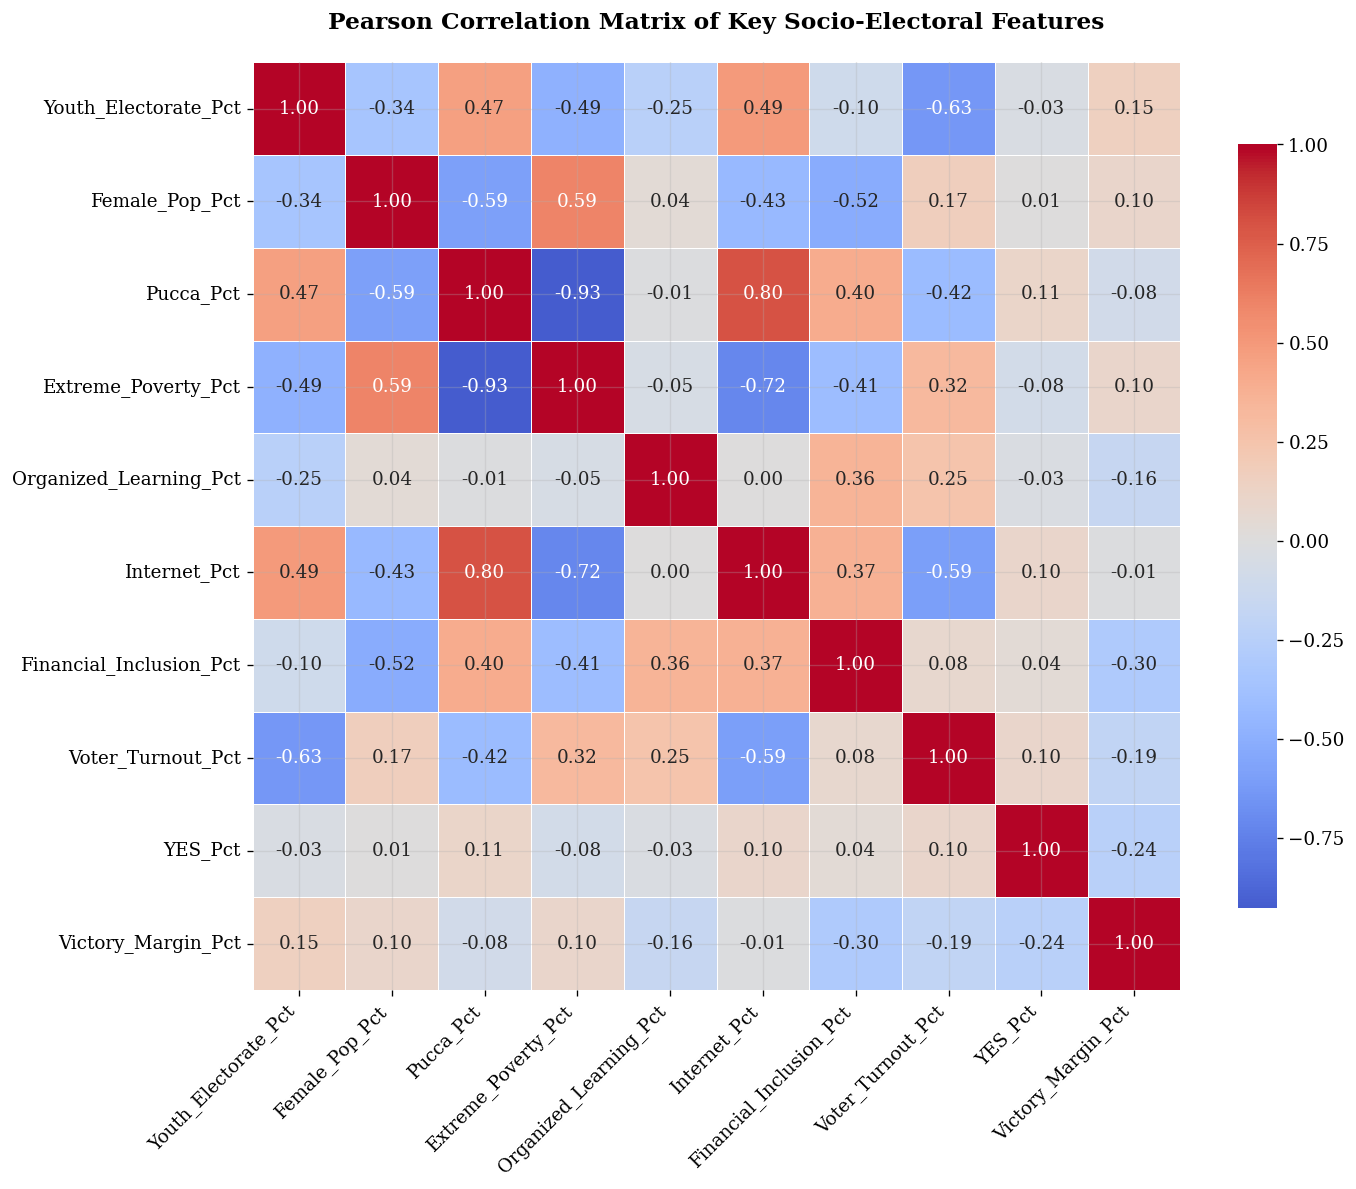

EDA Pipeline Complete.


In [6]:
# Select only continuous numeric columns for correlation
corr_cols = [
    "Youth_Electorate_Pct", "Female_Pop_Pct", "Pucca_Pct", "Extreme_Poverty_Pct",
    "Organized_Learning_Pct", "Internet_Pct", "Financial_Inclusion_Pct",
    "Voter_Turnout_Pct", "YES_Pct", "Victory_Margin_Pct"
]

corr_matrix = pdf[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)

ax.set_title("Pearson Correlation Matrix of Key Socio-Electoral Features", pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("EDA Pipeline Complete.")